In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
eeg = pd.read_csv("../Data/eeg_features.csv")
X = eeg[[
    "A31_spec_entropy",
    "C27_spec_entropy",
    "C6_spec_entropy",
    "H11_spec_entropy",
    "D18_spec_entropy",
    "H12_spec_entropy",
    "H17_spec_entropy",
    "H10_spec_entropy",
    "F18_spec_entropy",
    "H16_spec_entropy",
    "H22_spec_entropy",
    "H5_spec_entropy",
    "F29_spec_entropy",
    "D10_spec_entropy",
    "F16_spec_entropy",
    "H13_spec_entropy",
    "B8_spec_entropy",
    "F27_spec_entropy",
    "B2_spec_entropy"
]]
y = np.where(eeg["C4_bp_delta"] > eeg["C4_bp_delta"].median(), 1, 0)



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

log_model = LogisticRegression()
nb_model = MultinomialNB()

log_model.fit(X_train_scaled, y_train)
nb_model.fit(X_train, y_train)

preds_log = log_model.predict(X_test_scaled)
preds_nb = nb_model.predict(X_test_scaled)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


accuracy_score(preds_log, y_test)

0.8421052631578947

In [8]:
accuracy_score(preds_nb, y_test)

0.6842105263157895

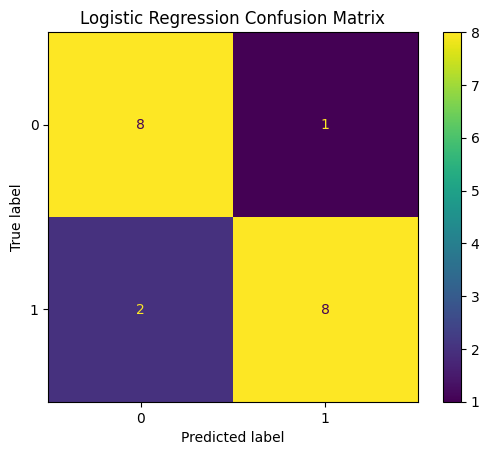

In [9]:
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, preds_log)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

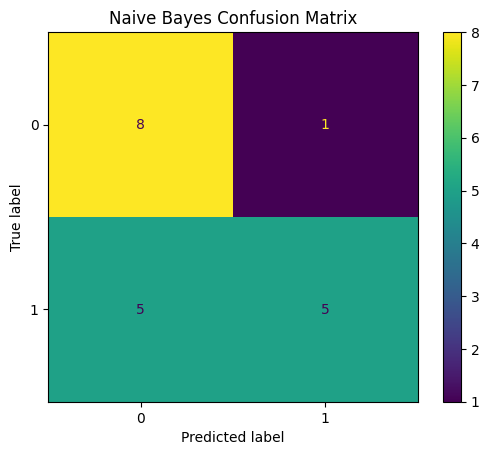

In [10]:
cm_nb = confusion_matrix(y_test, preds_nb)
ConfusionMatrixDisplay(cm_nb).plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()